# Chapter 2.1 - Extrapolation to zero cell size
This notebook implements the integration of a square with side length $2a$ over the kernel
\begin{equation}
    \frac{1}{\sqrt{x'^2 + y'^2 + z^2}}\, ,
\end{equation}
where $z$ is the observation point on the $z$-axis and $x'$ and $y'$ are the coordinates we are integrating about. See the textbook for details.

In [1]:
"""
    integr(z, a, n, rule)
    
    Returns potential at (0, 0, `z`) of a square with side length 2*`a`, 
    which is discretized in n segments using either the midpoint or
    the simpson integration rule.
"""
function integr(z::F, a::F, n, rule::String) where F <: Real
    
    # Note that I drop in the following the last element of the vector
    # because we do not need it to form our summation!
    # range(start,stop,length) or range(start,stop,step)
    xcoords = collect(range(F(0), stop = a, length = n + 1))[1:end-1] # range: Divide the range from 0 to a into n segments
    ycoords = collect(range(F(0), stop = a, length = n + 1))[1:end-1] # collect: turn the range object into a column vector
    
    
    h = a/n # Average mesh size
    zs = z^2 # (0,Save squaring computations
    
    int = F(0) # Here we store the return value
    
    # For convenience we define a function for the integrand
    # Note that it uses the zs from above
    k(x, y) = 1/sqrt(x^2 + y^2 + zs)
    
    if rule == "midpoint"
        
        # Precompute x- and y-coordinates
        
        for x in xcoords
            for y in ycoords
                int += k(x + h/2, y + h/2)
            end
        end        

    elseif rule == "trapezoid"
        
        for x in xcoords
            for y in ycoords
                int += k(x, y) + k(x, y + h) + k(x + h, y) + k(x + h, y + h)
            end
        end
        
        int = int/4
        
    elseif rule == "gaussquad"
        
        # Insert your code here
        
    elseif rule == "simpson"
        
        for x in xcoords
            for y in ycoords 
                int += k(x, y) + k(x, y + h) + k(x + h, y) + k(x + h, y + h)
                int += 4 * (k(x + h/2, y) + k(x + h/2, y + h) + k(x, y + h/2) + k(x + h, y + h/2))
                int += 16 * k(x + h/2, y + h/2)
            end
        end
        
        int = int/36
        
    else
        error("Rule is not supported")
    end
    
    return int*h^2
end

integr

## Unit tests
When writing code, it is advisable to write so-called unit tests, where you test the behavior of each and every function. One such test is shown below, where I ensure that if we pass the parameters of a certain type (e.g., `Float32`), then all the arithmetic is carried in this precision. Use the Julia-Package Test (it is part of the standard Julia library) and use the macro `@test` as shown below.

In [2]:
using Test

F = Float32
n = 100

for rule in ["midpoint" "trapezoid" "simpson"]
    @test eltype(integr(F(1.0),  F(1.0), n, rule)) == Float32
    @test eltype(integr(1.0, 1.0, n, rule)) == Float64
end

#eltype gives back type of the contained elements

## Sweeping and arrays
In the following, I have written a function sweeps over the provided number of segments and computes the results for midpoint, trapezoid, and simpson rule.

In [3]:
nvals32 = [5; 10; 20; 40; 80; 160; 320; 640; 1280]

function sweep_integration(a::F, z::F, nvals; verbose=false) where F

    # Store results
    I_midpoint = F[]
    res_trapezoid = F[]
    I_simpson = F[]
    hs = F[]
    for n in nvals
        push!(hs, a/n)
        push!(I_midpoint, integr(z, a, n, "midpoint"))
        push!(res_trapezoid, integr(z, a, n, "trapezoid"))
        push!(I_simpson, integr(z, a, n, "simpson"))
    end
    
    return hs, I_midpoint, res_trapezoid, I_simpson
end

hs32, I_midpoint32, I_trapezoid, I_simpson32 = sweep_integration(F(1.0), F(1.0), nvals32)

#When you push!(m,y) you are actually storing into m a reference to the array y, 
#instead of copying the contents. That’s why if you modify an element in y, 
#you will see the change in all of the elements of m: because you are actually looking inside the same y.

(Float32[0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625, 0.003125, 0.0015625, 0.00078125], Float32[0.794323, 0.79359996, 0.7934193, 0.7933747, 0.7933639, 0.7933602, 0.79336154, 0.79340434, 0.79423076], Float32[0.7914354, 0.79287827, 0.79323876, 0.79332924, 0.793353, 0.79335785, 0.7933609, 0.7934043, 0.79423076], Float32[0.7933595, 0.7933589, 0.7933591, 0.79335636, 0.7933619, 0.79336, 0.79335797, 0.79417944, 0.81262577])

## Formatted printing
The following function uses the `Printf`-package. This allows formatted printing similar to what `printf()` in C does.

In [4]:
using Printf
function print_results(nvals, hs, md, tp, sp)
    
    for (n, h, m, t, s) in zip(nvals, hs, md, tp, sp)
        @printf("%6d %10.6f %18.15f %18.15f %18.15f\n", n, h, m, t, s)
    end
end

print_results(nvals32, hs32, I_midpoint32, I_trapezoid, I_simpson32)

     5   0.200000  0.794323027133942  0.791435420513153  0.793359518051147
    10   0.100000  0.793599963188171  0.792878270149231  0.793358922004700
    20   0.050000  0.793419301509857  0.793238759040833  0.793359100818634
    40   0.025000  0.793374717235565  0.793329238891602  0.793356359004974
    80   0.012500  0.793363928794861  0.793353021144867  0.793361902236938
   160   0.006250  0.793360173702240  0.793357849121094  0.793359994888306
   320   0.003125  0.793361544609070  0.793360888957977  0.793357968330383
   640   0.001563  0.793404340744019  0.793404281139374  0.794179439544678
  1280   0.000781  0.794230759143829  0.794230759143829  0.812625765800476


## Dataframes
If you have worked with Python before, you might know Pandas. The DataFrames-Package is the Julia equivalent. It allows easy storage and manipulation of data.

In [5]:
using DataFrames

DataFrame(n=nvals32, h=hs32, midpoint=I_midpoint32, trapezoid=I_trapezoid, simpson=I_simpson32)

,n,h,midpoint,trapezoid,simpson
,Int64,Float32,Float32,Float32,Float32
1,5,0.2,0.794323,0.791435,0.79336
2,10,0.1,0.7936,0.792878,0.793359
3,20,0.05,0.793419,0.793239,0.793359
4,40,0.025,0.793375,0.793329,0.793356
5,80,0.0125,0.793364,0.793353,0.793362
6,160,0.00625,0.79336,0.793358,0.79336
7,320,0.003125,0.793362,0.793361,0.793358
8,640,0.0015625,0.793404,0.793404,0.794179
9,1280,0.00078125,0.794231,0.794231,0.812626


## Plotting
There are many packages in Julia for plotting. Some of them use existing backends, such as PyPlot. Some of the packages such as Makie implemented all plotting functionality natively in Julia. The package `Plots` is a meta-package and allows to use many of these backends with the same syntax. It is my recommendation.

### Caveat
As you can see, I optionally add something to the plot if a given keyword argument has been passed. Since I have stuffed everything into a function, it is necessary to explicit call the `display()` function to force Julia to generate the plot.

In [6]:
using Plots

function plot_integration_results(hs; md=nothing, tp=nothing, sp=nothing, legend=:topright)
    kwargs = Dict(:markersize=>6, :linewidth=>2, :markerstrokewidth=>3)
 = 
    plt = plot(xlabel="h in m", ylabel="Value of integration", legend=legend)

    # Note that when we check against 'nothing', we have to use '===' or '!=='
    md !== nothing && plot!(hs, md, label="Midpoint rule", markershape=:x, linestyle=:solid; kwargs...)
    tp !== nothing && plot!(hs, tp, label="Trapezoid rule", markershape=:o, linestyle=:solid; kwargs...)
    sp !== nothing && plot!(hs, sp, label="Simpson rule", markershape=:s, linestyle=:solid; kwargs...)
    display(plt)
end

plot_integration_results (generic function with 1 method)

## Machine precision and some consequences
Looking at the following plot, we see that we convergence for $h\rightarrow 0$ until a certain point, where it breaks down. We can attribute this to the machine precision limiting us to roughly `8` digits precision. Why would you use then `Float32`? Well, it uses less memory (4 bytes vs the 8 bytes of Float64) and it is faster. If you do not need more than 8 digits, you are fine to go with it.

┌ Info: Precompiling GR_jll [d2c73de3-f751-5644-a686-071e5b155ba9]
└ @ Base loading.jl:1662


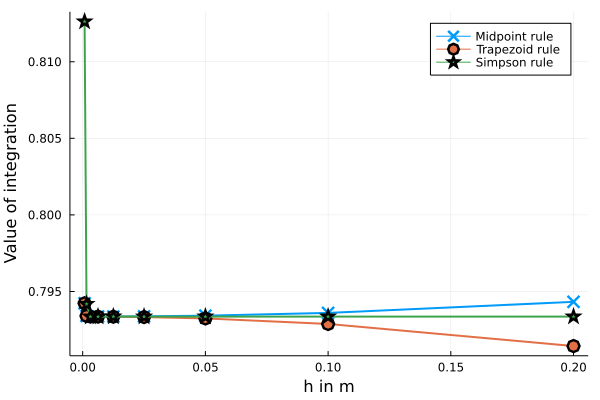

In [24]:
plot_integration_results(hs32, md=I_midpoint32, tp=I_trapezoid, sp=I_simpson32)

## Revisit with double precision
To see whether my conjecture is right and the reason of the breakdown is due to finite precision arithmetic, lets increase the precision to double.

In [25]:
nvals = [5; 10; 20; 40; 80; 160; 320; 640; 1280; 2560; 5120]
hs, I_midpoint, res_trapezoid, I_simpson = sweep_integration(1.0, 1.0, nvals)
print_results(nvals, hs, I_midpoint, res_trapezoid, I_simpson)

     5   0.200000  0.794323017128872  0.791435492544380  0.793359437809298
    10   0.100000  0.793599787331061  0.792878049821289  0.793359141307339
    20   0.050000  0.793419268450178  0.793238843365653  0.793359122578419
    40   0.025000  0.793374156894327  0.793329051208883  0.793359121404809
    80   0.012500  0.793362880142623  0.793351603757943  0.793359121331415
   160   0.006250  0.793360061025807  0.793357241931926  0.793359121326829
   320   0.003125  0.793359356251033  0.793358651477713  0.793359121326502
   640   0.001563  0.793359180057647  0.793359003864288  0.793359121326564
  1280   0.000781  0.793359136009199  0.793359091960944  0.793359121326517
  2560   0.000391  0.793359124997022  0.793359113985240  0.793359121326824
  5120   0.000195  0.793359122244276  0.793359119490717  0.793359121325907


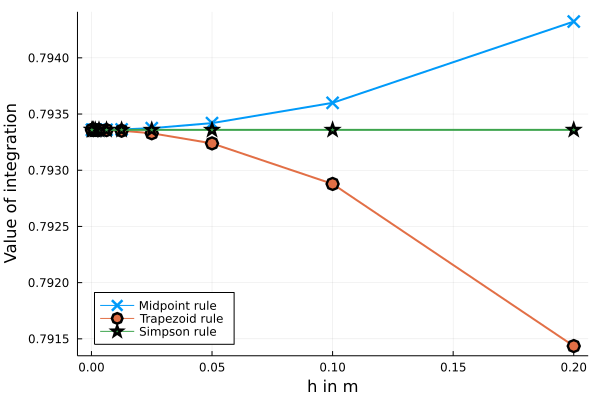

In [26]:
plot_integration_results(hs, md=I_midpoint, tp=res_trapezoid, sp=I_simpson, legend=:bottomleft)

We seem to be fine now reaching almost 16 digits of accuracy.

## Analytic solution: the anti-derivative
Below you find an anti-derivative. It is actually not really a useful anti-derivative, since it fails for $z=0$. However, if $z$ is large enough, it provides reasonable results. There are smarter ways to compute the integral analytically and I am happy to discuss with you.

anti_derivative $(x,y) = \log(\sqrt{x^2 + y^2 + z^2} + y) + y\log(\sqrt{x^2 + y^2 + z^2} + x) - z\arctan(\frac{xy}{z\sqrt{x^2 + y^2 + z^2}}) + z\arctan(\frac{x}{z})-x$

In [27]:
function analytic_integral(z::F, a::F) where F
    anti_derivative(x, y) = x*log(sqrt(x^2 + y^2 + z^2) + y) + y*log(sqrt(x^2 + y^2 + z^2) + x) - 
            z*atan(x*y/(z*sqrt(x^2 + y^2 + z^2))) + z*atan(x/z) - x
    #anti_derivative(x, y) = x*log(sqrt(x^2 + y^2 + z^2) + y) + y*log(sqrt(x^2 + y^2 + z^2) + x) + x
    return (anti_derivative(a, a) - anti_derivative(0, a)) - (anti_derivative(a, 0) - anti_derivative(0, 0))
end

analytic_integral (generic function with 1 method)

## BigFloat precision
If you really want to get accurate results beyond 16 digits, you can use the BigFloat data type, where you can actually set an arbitrary precision. The default BigFloat precision is sufficient for our purposes here.

In [28]:
println(analytic_integral(BigFloat(1.0), BigFloat(1)))

0.7933591213265178355479391167613846299941204049049988429393148248691574510353892


## Convergence plots
Plots are a useful means to rapidly assess data and figure out a trend. The plots suggest that we convergence (which would allow us to estimate the order of convergence and extrapolate to zero).

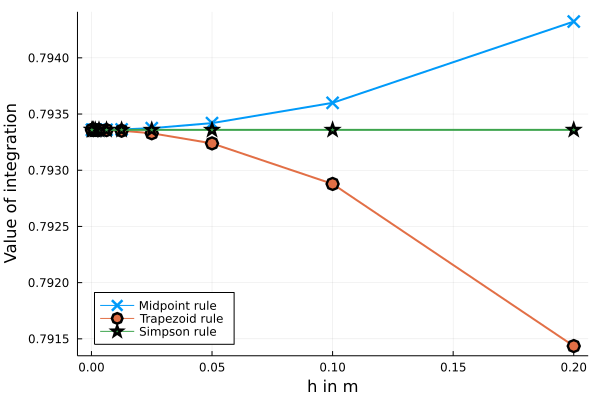

In [29]:
plot_integration_results(hs, md=I_midpoint, tp=res_trapezoid, sp=I_simpson, legend=:bottomleft)

### Close up
Clearly, it is difficult to exactly judge what is going on for $h \rightarrow 0$. Lets zoom in for each integration rule separately.

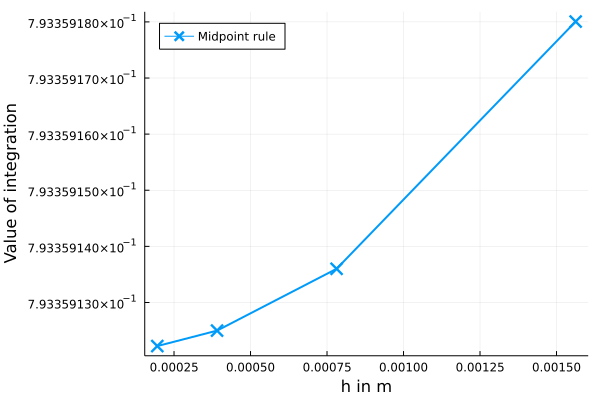

In [30]:
plot_integration_results(hs[end-3:end], md=I_midpoint[end-3:end], legend=:topleft)

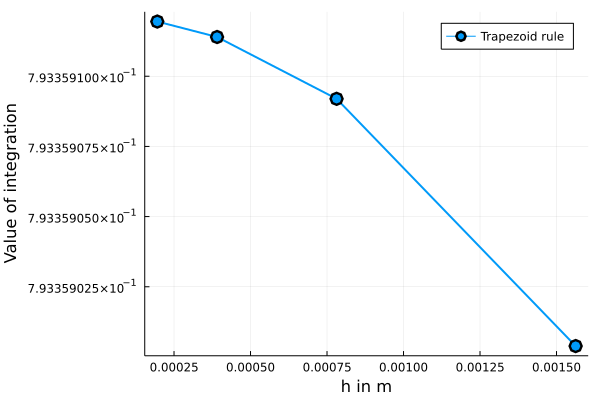

In [31]:
plot_integration_results(hs[end-3:end], tp=res_trapezoid[end-3:end], legend=:topright)

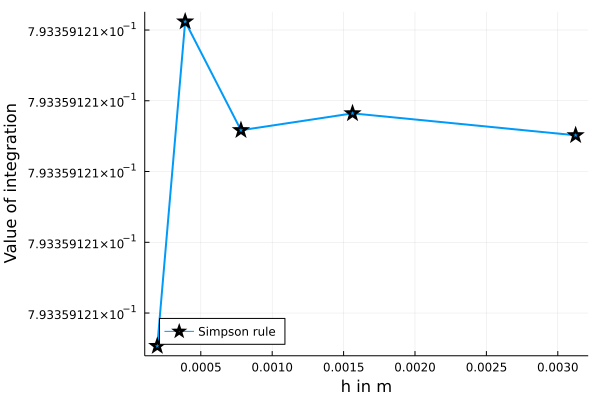

GKS: Possible loss of precision in routine SET_WINDOW


In [32]:
plot_integration_results(hs[end-4:end], sp = I_simpson[end-4:end], legend=:bottomleft)

**WARNING:** For midpoint and trapezoid rule, we observe convergence. However, for Simpson rule, because we reach machine precision for much larger $h$ than for midpoint and trapezoid rule, the results starts to oscillate. If we use the last data points, we will not be able to estimate the order of convergence and to extrapolate to zero cell size. Let's see for which data points we get a reasonable behavior by trial and error.

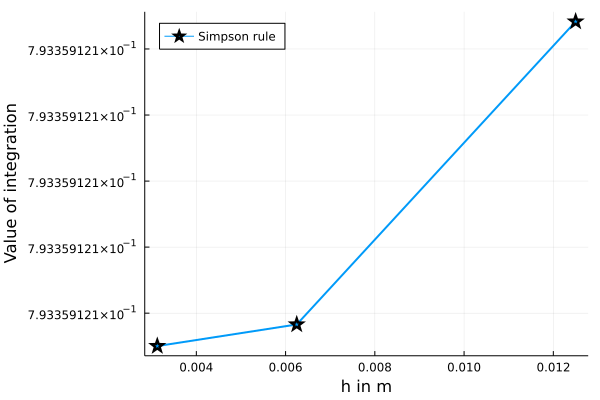

In [33]:
plot_integration_results(hs[end-6:end-4], sp = I_simpson[end-6:end-4], legend=:topleft)

Clearly, around the selected data points we might be able to correctly estimate the order of convergence.

## Estimating the order of convergence

In [35]:
function estimate_p(h, I)
    return log(abs((I[end-2] - I[end-1])/(I[end-1] - I[end])))/log(h[end-2]/h[end-1])
end

p_mid = estimate_p(hs, I_midpoint)
p_trapezoid = estimate_p(hs, res_trapezoid)
p_simpson_stupid = estimate_p(hs, I_simpson)
p_simpson_better = estimate_p(hs[end-6:end-4], I_simpson[end-6:end-4])
p_simpson = estimate_p(hs[end-7:end-5], I_simpson[end-7:end-5])


@printf("Estimated order of convergence (Midpoint): %8.6f\n", p_mid)
@printf("Estimated order of convergence (Trapezoid): %8.6f\n", p_trapezoid)
@printf("Estimated order of convergence (Simpson, stupid): %8.6f\n", p_simpson_stupid)
@printf("Estimated order of convergence (Simpson, better): %8.6f\n", p_simpson_better)
@printf("Estimated order of convergence (Simpson): %8.6f\n", p_simpson)

Estimated order of convergence (Midpoint): 2.000156
Estimated order of convergence (Trapezoid): 2.000156
Estimated order of convergence (Simpson, stupid): -1.578515
Estimated order of convergence (Simpson, better): 3.809452
Estimated order of convergence (Simpson): 4.000461


**Moral:** You need to be careful when estimating the order of convergence! Due to machine precision etc. the results can be distorted. Plots can help to select the correct part of the data, where you can reasonable estimate convergence and extrapolate to zero cell size.

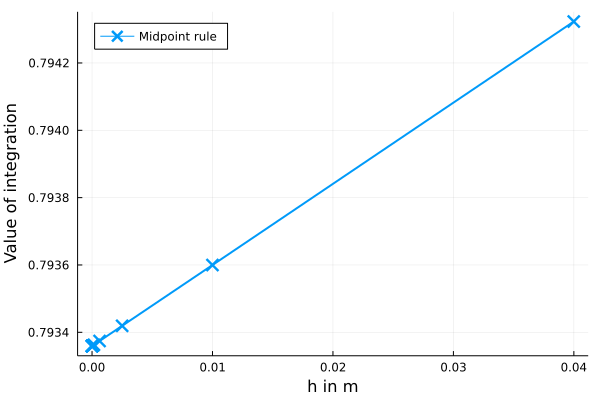

In [36]:
plot_integration_results(hs.^p_mid, md=I_midpoint, legend=:topleft)

By plotting against $h^p$, we get a straight line. Clearly, we could extrapolate this line and extrapolate the value, we are converging against.

## Extrapolation to zero cell size

In [37]:
using Polynomials

# Let's fit a polynom of degree 4 and see which coefficients dominate 
# We first make the look like a "line" (see previous plot)
# so even a polynom of degree 1 should be a good approximation
# In doing so, we do not need to raise the order of our polynomial approximatino
# when we go to a higher degree
pfit_midpoint = fit(hs[end-3:end].^p_mid, I_midpoint[end-3:end], 4)
pfit_trapezoid = fit(hs[end-3:end].^p_trapezoid, res_trapezoid[end-3:end], 4)
pfit_simpson = fit(hs[end-8:end-5].^p_simpson, I_simpson[end-8:end-5], 4)

ex_midpoint = pfit_midpoint(0.0)
ex_trapezoid = pfit_trapezoid(0.0)
ex_simpson = pfit_simpson(0.0)

I = analytic_integral(BigFloat(1.0), BigFloat(1))

function print_extra(rule, Iex, Irule, I) 
    @printf("Extrapolated result for %s: %18.15f (accuracy %4.2f dB, without extrapolation %4.2f dB) \n", rule, Iex, 10*log10(abs(Iex-I)/abs(I)), 10*log10(abs(Irule-I)/abs(I)) )
end

print_extra("midpoint", ex_midpoint, last(I_midpoint), I) 
print_extra("trapezoid", ex_trapezoid, last(I_midpoint), I) 
print_extra("Simpson", ex_simpson,I_simpson[end-5] , I) 

Extrapolated result for midpoint:  0.793359121326770 (accuracy -124.98 dB, without extrapolation -89.37 dB) 
Extrapolated result for trapezoid:  0.793359121325723 (accuracy -119.99 dB, without extrapolation -89.37 dB) 
Extrapolated result for Simpson:  0.793359121326524 (accuracy -141.36 dB, without extrapolation -124.06 dB) 


We can see that with extrapolation we can gain additional digits. 

## Observation point at $z=0$

In [38]:
nvals = [5; 10; 20; 40; 80; 160; 320; 640; 1280; 2560; 5120]
hs, I_midpoint, res_trapezoid, I_simpson = sweep_integration(1.0, 0.0, nvals)
print_results(nvals, hs, I_midpoint, res_trapezoid, I_simpson)

     5   0.200000  1.684319695937456                Inf                Inf
    10   0.100000  1.722947399038047                Inf                Inf
    20   0.050000  1.742700175985771                Inf                Inf
    40   0.025000  1.752686859278451                Inf                Inf
    80   0.012500  1.757707810336274                Inf                Inf
   160   0.006250  1.760225190457622                Inf                Inf
   320   0.003125  1.761485606806515                Inf                Inf
   640   0.001563  1.762116246561835                Inf                Inf
  1280   0.000781  1.762431674335244                Inf                Inf
  2560   0.000391  1.762589415195953                Inf                Inf
  5120   0.000195  1.762668292369717                Inf                Inf


**Discussion:** Clearly, trapezoid and Simpson rule are useless here, since they lead to a division by zero.

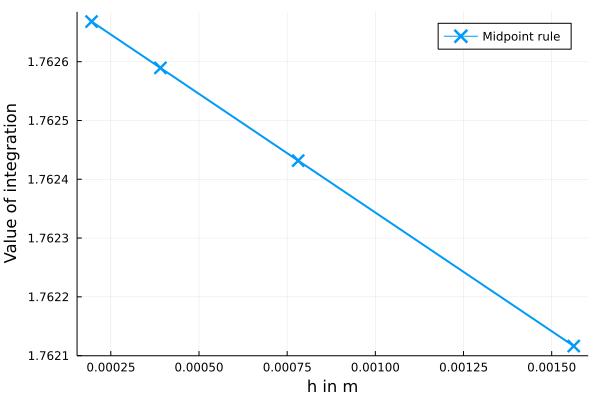

In [22]:
plot_integration_results(hs[end-3:end], md=I_midpoint[end-3:end], legend=:topright)

The good news is that midpoint rule still converges.

### Order of convergence for midpoint rule and $z=0$

In [23]:
p_mid0 = estimate_p(hs, I_midpoint)

@printf("Estimated order of convergence (Midpoint): %8.6f\n", p_mid0)

Estimated order of convergence (Midpoint): 0.999877


Due to the singularity, the function we are integrating is not smooth anymore. We derived the order of convergence for the midpoint rule based on a Taylor series. However, if the integrand is singular, we cannot form the Taylor series around the singularity and thus our previous analysis cannot be used to predict the order of convergence. The numerical estimate indicates that the order of convergence is reduced from $\mathcal O(h^2)$ to $\mathcal O(h)$. 